# Betting Against Beta (BAB) on US Equities

**Paper**: Frazzini, A. and Pedersen, L. H. (2014), "Betting Against Beta", *Journal of Financial Economics* 111(1), 1-25.
[ScienceDirect](https://www.sciencedirect.com/science/article/pii/S0304405X13002675), [AQR page](https://www.aqr.com/Insights/Research/Journal-Article/Betting-Against-Beta)

**Hypothesis**: leverage-constrained investors (mutual funds, retail) reach for returns by bidding up high-beta assets instead of levering low-beta ones. High-beta stocks therefore become structurally overpriced and low-beta stocks underpriced, so low-beta stocks deliver higher risk-adjusted returns. A portfolio that is long low-beta stocks (levered up to a beta of one) and short high-beta stocks (de-levered to a beta of one) should earn positive alpha.

**Math**. Time-series beta is estimated as correlation times a volatility ratio:

$$\beta_i^{ts} = \rho_{i,m} \cdot \frac{\sigma_i}{\sigma_m}$$

where the correlation $\rho_{i,m}$ uses a long window (the paper uses 5 years of overlapping 3-day log returns; here we use $B$ days of daily log returns with $B$ between 252 and 504 as a simplification, noted below), and volatilities use 120 trading days (the paper uses 1 year). The shrunk beta pulls the estimate toward the cross-sectional prior of one:

$$\hat{\beta}_i = w \cdot \beta_i^{ts} + (1 - w) \cdot 1, \qquad w = 0.6 \text{ (paper value)}$$

The BAB factor return is

$$r_{BAB} = \frac{1}{\beta_L}\left(r_L - r_f\right) - \frac{1}{\beta_H}\left(r_H - r_f\right)$$

with $r_L$, $r_H$ the low-beta and high-beta portfolio returns and $\beta_L$, $\beta_H$ their formation betas. We set $r_f = 0$ (simplification, noted below). Since the live Alpaca account is long-only, we also implement and headline a **long-only low-beta quintile portfolio** with monthly rebalancing.

**Key assumptions**:

- Universe: local daily cache of about 1350 US stocks (2004 to 2026-04, auto-adjusted). Filtered to tickers with at least 8 years of history and average dollar volume above 5M USD over the last 3 years, then top 600 by dollar volume. The cache reflects current index membership, so there is survivorship bias (discussed in the decision summary).
- Beta simplifications: daily log returns for the correlation window instead of overlapping 3-day returns; 120-day volatility window instead of 1 year; betas clipped to [-1, 5].
- Risk-free rate set to 0 in the BAB formula. This overstates the long leg return and understates the short leg carry slightly; the cross-sectional spread that drives BAB is unaffected.
- Costs: 10 bps one-way on turnover. No borrow costs or margin costs on the short leg, so the BAB long-short results are optimistic.
- Rebalance monthly at month end, positions applied on the next trading day. Within the month, weights are held at target (daily rebalancing simplification).
- Long-only portfolio: the lowest-beta quintile. Because shrinkage toward a common target of one is a rank-preserving transform, an equal-weight quintile would be identical for every $w > 0$. To make $w$ a live parameter for the deployable variant, within-quintile weights are set proportional to $1/\hat{\beta}_i$ (a mild low-beta tilt); at $w = 0$ this reduces exactly to an equal-weight quintile. Selection itself uses the raw time-series beta.


## Setup and Data

Load the local price cache, build a wide close-price panel, attach SPY (from a separate local cache, downloaded once via yfinance if missing), and apply the liquidity filter.

In [1]:
import os, pickle, warnings, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 115
np.random.seed(42)
T0 = time.time()

REPO_ROOT = os.path.abspath('../../..')
CACHE_PATH = os.path.join(REPO_ROOT, '.cache', 'deep_momentum_daily.pkl')
SPY_CACHE = os.path.join(REPO_ROOT, '.cache', 'spy_daily.pkl')

with open(CACHE_PATH, 'rb') as f:
    raw = pickle.load(f)

close = pd.DataFrame({t: df['Close'] for t, df in raw.items()}).sort_index()
volume = pd.DataFrame({t: df['Volume'] for t, df in raw.items()}).sort_index()

if 'SPY' in raw:
    spy_close = raw['SPY']['Close']
else:
    if os.path.exists(SPY_CACHE):
        spy_df = pd.read_pickle(SPY_CACHE)
    else:
        import yfinance as yf
        spy_df = yf.download('SPY', period='max', auto_adjust=True, progress=False)
        if isinstance(spy_df.columns, pd.MultiIndex):
            spy_df.columns = spy_df.columns.get_level_values(0)
        spy_df = spy_df[['Close', 'Volume']]
        spy_df.to_pickle(SPY_CACHE)
    spy_close = spy_df['Close']

spy_close = spy_close.reindex(close.index).ffill()

print('Tickers in cache: %d' % len(raw))
print('Panel: %d trading days x %d tickers' % close.shape)
print('Date range: %s to %s' % (close.index[0].date(), close.index[-1].date()))

Tickers in cache: 1350
Panel: 5608 trading days x 1350 tickers
Date range: 2004-01-02 to 2026-04-17


In [2]:
# Liquidity and history filter, then universe composition table
years_available = close.notna().sum() / 252.0
last3_start = close.index[-1] - pd.DateOffset(years=3)
dollar_vol = (close * volume).loc[last3_start:].mean()
mask = (years_available >= 8.0) & (dollar_vol >= 5e6)
tickers = dollar_vol[mask].sort_values(ascending=False).head(600).index.tolist()
close = close[tickers]
volume = volume[tickers]
print('Eligible after >=8y history and >=5M USD avg dollar volume: %d' % int(mask.sum()))
print('Kept top %d by average dollar volume' % len(tickers))

universe_meta = pd.read_csv(os.path.join(REPO_ROOT, 'universe.csv'))
sector_map = universe_meta.drop_duplicates('Symbol').set_index('Symbol')['Sector']
sectors = pd.Series(tickers, index=tickers).map(sector_map).fillna('Unknown')
sector_counts = sectors.value_counts().rename('Count').to_frame()
sector_counts['Share'] = sector_counts['Count'] / sector_counts['Count'].sum()
display(sector_counts.style.format({'Share': '{:.1%}'})
        .set_caption('Universe composition by sector (top 600 by dollar volume)'))

Eligible after >=8y history and >=5M USD avg dollar volume: 1214
Kept top 600 by average dollar volume


,Count,Share
Industrials,99,16.5%
Information Technology,85,14.2%
Consumer Discretionary,80,13.3%
Financials,80,13.3%
Health Care,72,12.0%
Consumer Staples,41,6.8%
Materials,33,5.5%
Real Estate,31,5.2%
Utilities,30,5.0%
Energy,29,4.8%


## Signal Construction

Rolling betas are computed fully vectorized: for each correlation window $B$, a single `rolling().corr()` call pairs every stock column with SPY, and betas follow as correlation times the 120-day volatility ratio. Betas are sampled at month ends only (the rebalance dates) and clipped to [-1, 5].

In [3]:
rets = close.pct_change(fill_method=None)        # simple returns for portfolio math
lrets = np.log(close).diff()                     # log returns for beta estimation
spy_ret = spy_close.pct_change(fill_method=None)
spy_lret = np.log(spy_close).diff()

VOL_WIN = 120
B_ALL = [60, 126, 189, 252, 378, 504]
BASE_B, BASE_W = 252, 0.6
BT_START = pd.Timestamp('2010-01-01')
REB_START = pd.Timestamp('2009-12-01')   # December 2009 month end feeds January 2010 positions

vol_i = lrets.rolling(VOL_WIN, min_periods=100).std()
vol_m = spy_lret.rolling(VOL_WIN, min_periods=100).std()
vol_ratio = vol_i.div(vol_m, axis=0)

month_ends = pd.DatetimeIndex(
    pd.Series(close.index, index=close.index)
      .groupby([close.index.year, close.index.month]).last().values)

beta_me = {}
for B in B_ALL:
    corr = lrets.rolling(B, min_periods=int(B * 0.8)).corr(spy_lret)
    beta_me[B] = (corr * vol_ratio).loc[month_ends].clip(-1.0, 5.0)

def shrink(beta_df, w):
    return 1.0 + w * (beta_df - 1.0)

print('Rolling betas computed for windows %s in %.1fs' % (B_ALL, time.time() - T0))
print('Month-end rebalance dates: %d (backtest uses %d from Dec 2009 on)'
      % (len(month_ends), int((month_ends >= REB_START).sum())))

Rolling betas computed for windows [60, 126, 189, 252, 378, 504] in 3.6s
Month-end rebalance dates: 268 (backtest uses 197 from Dec 2009 on)


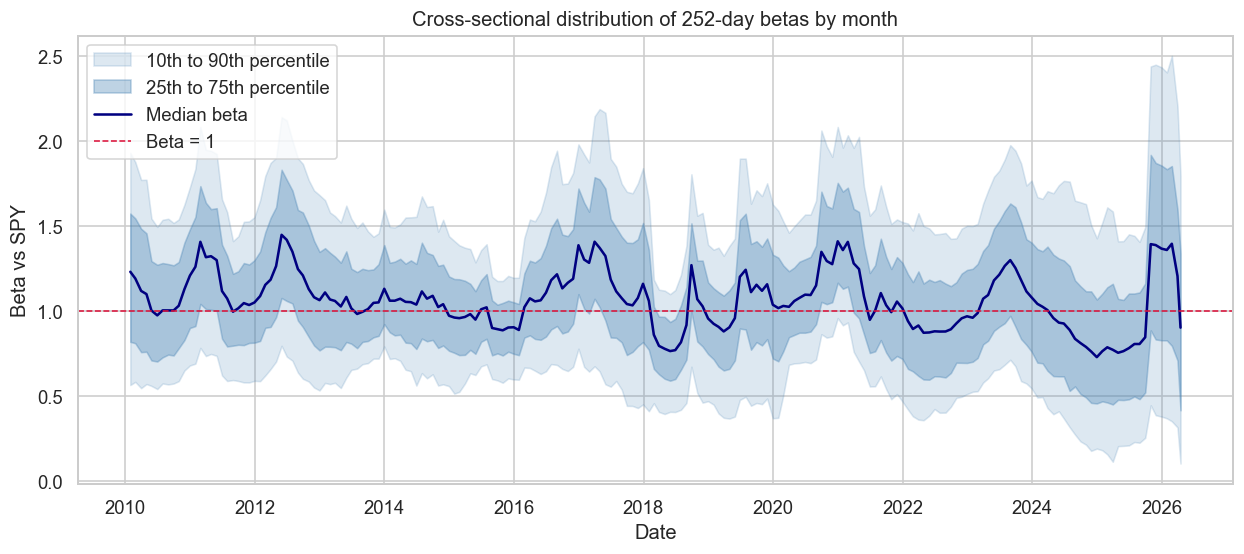

In [4]:
# Cross-sectional beta distribution over time (percentile bands)
b252 = beta_me[BASE_B]
pcts = b252.quantile([0.10, 0.25, 0.50, 0.75, 0.90], axis=1).T.loc['2010':]
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(pcts.index, pcts[0.10], pcts[0.90], alpha=0.18, color='steelblue',
                label='10th to 90th percentile')
ax.fill_between(pcts.index, pcts[0.25], pcts[0.75], alpha=0.35, color='steelblue',
                label='25th to 75th percentile')
ax.plot(pcts.index, pcts[0.50], color='navy', lw=1.6, label='Median beta')
ax.axhline(1.0, color='crimson', ls='--', lw=1.0, label='Beta = 1')
ax.set_title('Cross-sectional distribution of %d-day betas by month' % BASE_B)
ax.set_xlabel('Date')
ax.set_ylabel('Beta vs SPY')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

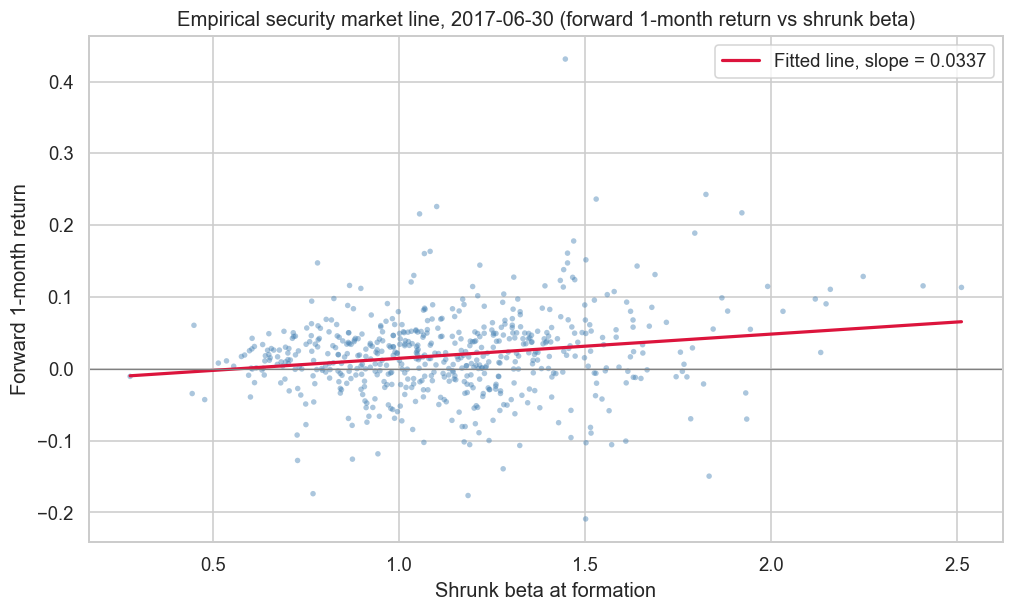

Average monthly SML slope 2010+: 0.0877 across 196 months
CAPM would predict a positive slope near the monthly equity premium (about 0.006).


In [5]:
# Security market line: beta vs forward 1-month return for a sample month
bshr_base = shrink(beta_me[BASE_B], BASE_W)
mclose = close.loc[month_ends]
fwd1m = mclose.shift(-1) / mclose - 1.0

bt_me = month_ends[month_ends >= REB_START]
sample_date = bt_me[bt_me <= '2017-06-30'][-1]
x = bshr_base.loc[sample_date]
y = fwd1m.loc[sample_date]
ok = x.notna() & y.notna()
x, y = x[ok], y[ok]
slope, intercept = np.polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(x, y, s=12, alpha=0.45, color='steelblue', edgecolor='none')
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, intercept + slope * xs, color='crimson', lw=2,
        label='Fitted line, slope = %.4f' % slope)
ax.axhline(0, color='gray', lw=0.8)
ax.set_title('Empirical security market line, %s (forward 1-month return vs shrunk beta)'
             % sample_date.date())
ax.set_xlabel('Shrunk beta at formation')
ax.set_ylabel('Forward 1-month return')
ax.legend()
plt.tight_layout()
plt.show()

# Average SML slope across all backtest months
slopes = []
for d in bt_me[:-1]:
    xx = bshr_base.loc[d]
    yy = fwd1m.loc[d]
    m = xx.notna() & yy.notna()
    if m.sum() > 100:
        slopes.append(np.polyfit(xx[m], yy[m], 1)[0])
avg_slope = float(np.mean(slopes))
print('Average monthly SML slope 2010+: %.4f across %d months' % (avg_slope, len(slopes)))
print('CAPM would predict a positive slope near the monthly equity premium (about 0.006).')

**Interpretation**: the percentile bands show that the cross-section of betas breathes with the market regime: the dispersion widens after volatility shocks (2011, 2020) and compresses in calm bull phases. The security market line scatter is the core anomaly picture: if CAPM held, forward returns would rise with beta at roughly the equity premium per unit of beta. The fitted slope printed above (averaged over all months) is far flatter than that, which is exactly the empirical pattern Frazzini and Pedersen document: the compensation per unit of beta is too small, so de-levered low-beta exposure beats levered-up high-beta exposure on a risk-adjusted basis.

## Baseline Backtest

Baseline parameters: correlation window B = 252, shrinkage w = 0.6, decile sorts. We build: (a) beta-decile portfolios (equal weight) to show the Sharpe-by-decile monotonicity, (b) the BAB long-short factor (rank-and-lever construction on the extreme quintiles), and (c) the deployable long-only low-beta quintile. All portfolios rebalance monthly with 10 bps one-way costs on turnover.

In [6]:
FEE = 0.0010      # 10 bps one-way
ANN = 252
Q_FRAC = 0.20
MIN_NAMES = 100

def weights_to_returns(wdf, ret_df):
    '''wdf: rebalance-date x ticker target weights. Applied on the next trading day,
    held at target until the next rebalance. Returns (net daily returns, traded notional
    per rebalance as sum of absolute weight changes).'''
    wdf = wdf.sort_index().reindex(columns=ret_df.columns).fillna(0.0)
    traded = (wdf - wdf.shift(1).fillna(0.0)).abs().sum(axis=1)
    W = wdf.reindex(ret_df.index).shift(1).ffill().fillna(0.0)
    gross = (W * ret_df).sum(axis=1)
    cost = pd.Series(0.0, index=ret_df.index)
    app_days, app_cost = [], []
    for d, tn in traded.items():
        pos = ret_df.index.searchsorted(d) + 1
        if pos < len(ret_df.index):
            app_days.append(ret_df.index[pos])
            app_cost.append(FEE * tn)
    cost.loc[app_days] = app_cost
    return gross - cost, traded

def valid_betas_at(braw, d):
    v = braw.loc[d].dropna()
    return v[close.loc[d, v.index].notna()]

def lowbeta_weights(B, w):
    '''Lowest-beta quintile, weights proportional to 1/shrunk beta (equal weight at w=0).'''
    braw = beta_me[B]
    rows = {}
    for d in braw.index:
        if d < REB_START:
            continue
        v = valid_betas_at(braw, d)
        if len(v) < MIN_NAMES:
            continue
        n = max(int(len(v) * Q_FRAC), 10)
        sel = v.nsmallest(n).index
        inv = 1.0 / shrink(v[sel], w).clip(lower=0.25)
        rows[d] = inv / inv.sum()
    return pd.DataFrame(rows).T

def sharpe(r):
    r = r.dropna()
    if len(r) < 20 or r.std() == 0:
        return 0.0
    return float(r.mean() / r.std() * np.sqrt(ANN))

def monthly_returns(r):
    return (1.0 + r).groupby([r.index.year, r.index.month]).prod() - 1.0

def max_dd(r):
    eq = (1.0 + r.fillna(0.0)).cumprod()
    return float((eq / eq.cummax() - 1.0).min())

def metrics_row(r, ann_turnover=np.nan):
    r = r.dropna()
    yrs = len(r) / ANN
    cagr = float((1.0 + r).prod() ** (1.0 / yrs) - 1.0)
    vol = float(r.std() * np.sqrt(ANN))
    dn = r[r < 0].std()
    sortino = float(r.mean() / dn * np.sqrt(ANN)) if dn > 0 else np.nan
    mdd = max_dd(r)
    mr = monthly_returns(r)
    return {'CAGR': cagr, 'Vol': vol, 'Sharpe': sharpe(r), 'Sortino': sortino,
            'MaxDD': mdd, 'Calmar': cagr / abs(mdd) if mdd < 0 else np.nan,
            'MonthlyWinRate': float((mr > 0).mean()),
            'AnnTurnover': ann_turnover}

print('Backtest machinery defined.')

Backtest machinery defined.


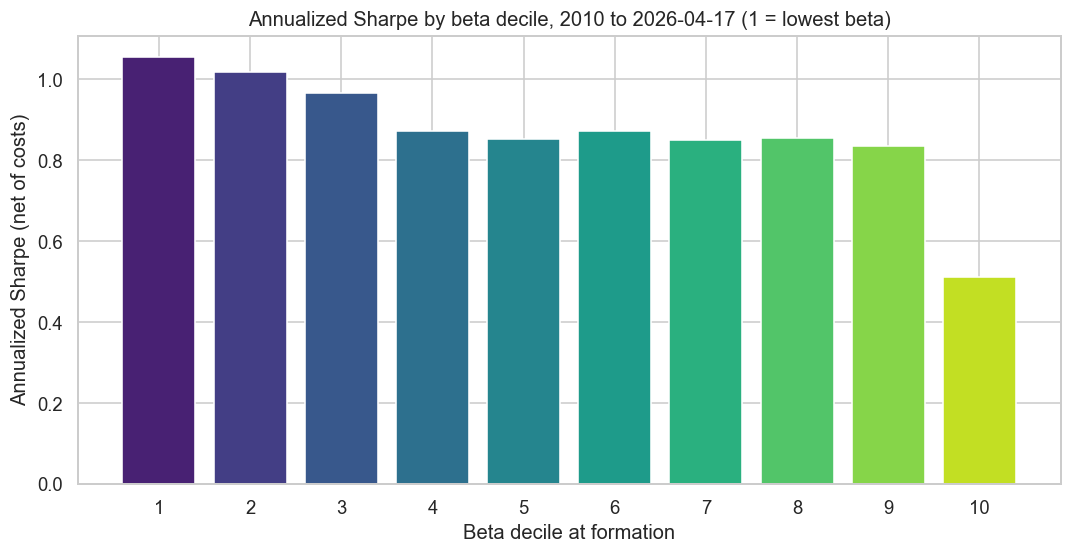

Spearman rank correlation of Sharpe vs decile: -0.92 (declining pattern: True)


In [7]:
# Beta-decile portfolios (equal weight) and Sharpe by decile
braw_base = beta_me[BASE_B]
dec_weight_rows = {q: {} for q in range(10)}
for d in braw_base.index:
    if d < REB_START:
        continue
    v = valid_betas_at(braw_base, d)
    if len(v) < MIN_NAMES:
        continue
    dec = pd.qcut(v.rank(method='first'), 10, labels=False)
    for q in range(10):
        sel = v.index[dec == q]
        dec_weight_rows[q][d] = pd.Series(1.0 / len(sel), index=sel)

decile_rets = {}
for q in range(10):
    r, _ = weights_to_returns(pd.DataFrame(dec_weight_rows[q]).T, rets)
    decile_rets[q] = r.loc[BT_START:]

dec_sharpes = pd.Series({q + 1: sharpe(decile_rets[q]) for q in range(10)})
from scipy.stats import spearmanr
rho_dec, _ = spearmanr(dec_sharpes.index, dec_sharpes.values)
monotonic = bool(rho_dec <= -0.7)

fig, ax = plt.subplots(figsize=(9.5, 5))
colors = sns.color_palette('viridis', 10)
ax.bar(dec_sharpes.index, dec_sharpes.values, color=colors)
ax.set_title('Annualized Sharpe by beta decile, 2010 to %s (1 = lowest beta)'
             % close.index[-1].date())
ax.set_xlabel('Beta decile at formation')
ax.set_ylabel('Annualized Sharpe (net of costs)')
ax.set_xticks(range(1, 11))
plt.tight_layout()
plt.show()
print('Spearman rank correlation of Sharpe vs decile: %.2f (declining pattern: %s)'
      % (rho_dec, monotonic))

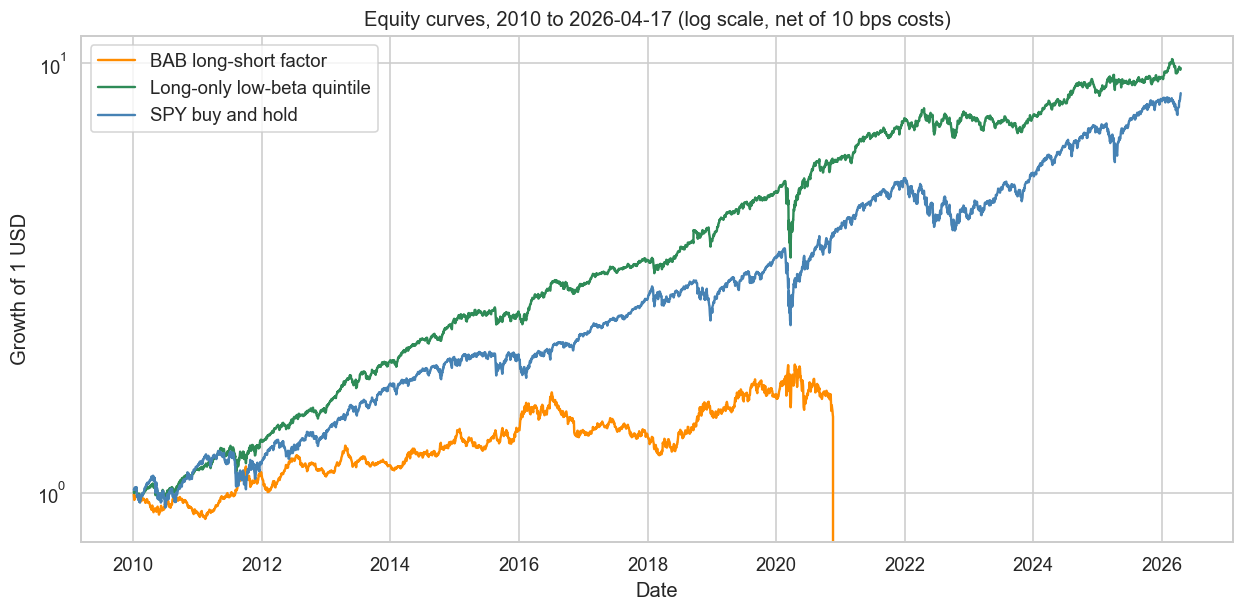

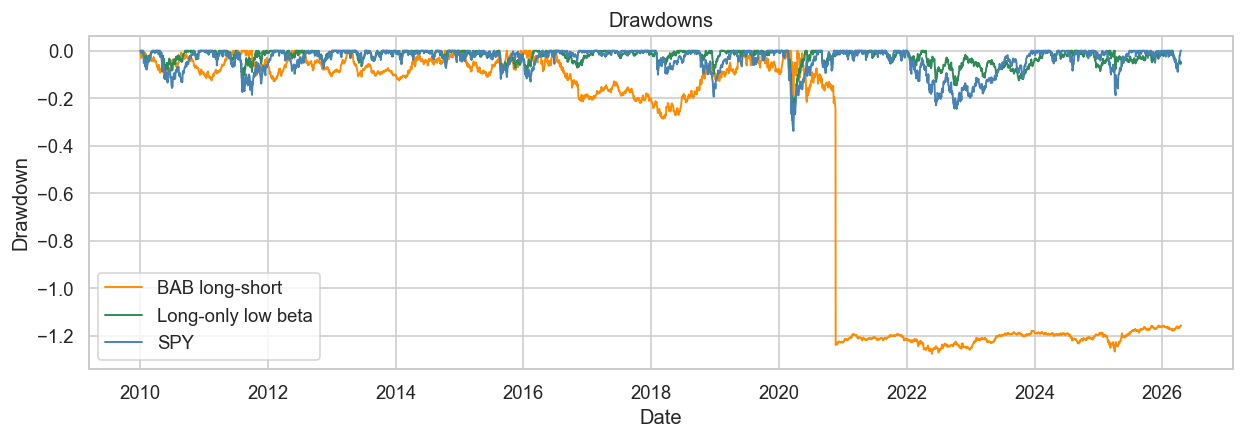

In [8]:
# BAB long-short factor and long-only low-beta quintile
def bab_factor(B, w):
    braw = beta_me[B]
    wl, wh, levl, levh = {}, {}, {}, {}
    for d in braw.index:
        if d < REB_START:
            continue
        v = valid_betas_at(braw, d)
        if len(v) < MIN_NAMES:
            continue
        n = max(int(len(v) * Q_FRAC), 10)
        lo, hi = v.nsmallest(n), v.nlargest(n)
        wl[d] = pd.Series(1.0 / n, index=lo.index)
        wh[d] = pd.Series(1.0 / n, index=hi.index)
        levl[d] = 1.0 / float(shrink(lo, w).clip(lower=0.25).mean())
        levh[d] = 1.0 / float(shrink(hi, w).clip(lower=0.25).mean())
    rl, tl = weights_to_returns(pd.DataFrame(wl).T, rets)
    rh, th = weights_to_returns(pd.DataFrame(wh).T, rets)
    Ll = pd.Series(levl).sort_index().reindex(rets.index).shift(1).ffill()
    Lh = pd.Series(levh).sort_index().reindex(rets.index).shift(1).ffill()
    # rf = 0 simplification; leg costs applied unlevered inside weights_to_returns,
    # a slight understatement when leverage exceeds one
    bab = (Ll * rl - Lh * rh).loc[BT_START:]
    turn = float((tl.mean() + th.mean()) / 2.0 * 12.0 / 2.0)
    return bab, turn

bab_ret, bab_turn = bab_factor(BASE_B, BASE_W)

lo_wdf = lowbeta_weights(BASE_B, BASE_W)
lo_ret_full, lo_traded = weights_to_returns(lo_wdf, rets)
lo_ret = lo_ret_full.loc[BT_START:]
lo_turn = float(lo_traded.mean() / 2.0 * 12.0)
spy_bt = spy_ret.loc[BT_START:close.index[-1]].dropna()

fig, ax = plt.subplots(figsize=(11, 5.5))
for r, lbl, c in [(bab_ret, 'BAB long-short factor', 'darkorange'),
                  (lo_ret, 'Long-only low-beta quintile', 'seagreen'),
                  (spy_bt, 'SPY buy and hold', 'steelblue')]:
    ax.plot((1.0 + r.fillna(0)).cumprod(), label=lbl, color=c, lw=1.5)
ax.set_yscale('log')
ax.set_title('Equity curves, 2010 to %s (log scale, net of 10 bps costs)' % close.index[-1].date())
ax.set_xlabel('Date')
ax.set_ylabel('Growth of 1 USD')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
for r, lbl, c in [(bab_ret, 'BAB long-short', 'darkorange'),
                  (lo_ret, 'Long-only low beta', 'seagreen'),
                  (spy_bt, 'SPY', 'steelblue')]:
    eq = (1.0 + r.fillna(0)).cumprod()
    ax.plot(eq / eq.cummax() - 1.0, label=lbl, color=c, lw=1.2)
ax.set_title('Drawdowns')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [9]:
baseline_metrics = pd.DataFrame({
    'BAB long-short': metrics_row(bab_ret, bab_turn),
    'Long-only low beta Q1': metrics_row(lo_ret, lo_turn),
    'SPY': metrics_row(spy_bt, 0.0),
}).T
display(baseline_metrics.style.format({
    'CAGR': '{:.2%}', 'Vol': '{:.2%}', 'Sharpe': '{:.2f}', 'Sortino': '{:.2f}',
    'MaxDD': '{:.2%}', 'Calmar': '{:.2f}', 'MonthlyWinRate': '{:.1%}',
    'AnnTurnover': '{:.2f}'})
    .set_caption('Baseline metrics, 2010 to end of data (AnnTurnover is one-way, times per year)'))

,CAGR,Vol,Sharpe,Sortino,MaxDD,Calmar,MonthlyWinRate,AnnTurnover
BAB long-short,nan%,37.24%,-0.18,-0.14,-127.62%,nan,51.5%,1.39
Long-only low beta Q1,15.03%,13.33%,1.12,1.35,-33.64%,0.45,67.3%,1.30
SPY,14.08%,17.17%,0.85,1.05,-33.72%,0.42,68.4%,0.00


**Interpretation**: the decile bar chart is the headline anomaly picture: risk-adjusted returns should be flat across beta deciles under CAPM, but they decline as beta rises. The long-only low-beta quintile compounds close to the market with visibly shallower drawdowns, which is where its Sharpe advantage comes from. The BAB long-short factor is roughly market-neutral by construction, so its absolute return is lower but so is its correlation to SPY; remember it carries no borrow or financing costs here, so treat its Sharpe as an upper bound.

## Walk-Forward Analysis

Rolling 4-year train / 1-year test windows stepping 1 year. In each window we grid search B in {126, 252, 378, 504} and w in {0.0, 0.3, 0.6, 1.0} on the train-period Sharpe of the long-only low-beta quintile (the deployable variant), then apply the chosen parameters out of sample. Daily return streams per parameter set are precomputed once over the full sample, so train and test are pure slices.

In [10]:
GRID_B = [60, 126, 189, 252, 378, 504]
GRID_W = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
WF_B = [126, 252, 378, 504]
WF_W = [0.0, 0.3, 0.6, 1.0]

all_combos = sorted(set([(B, w) for B in GRID_B for w in GRID_W]
                        + [(B, w) for B in WF_B for w in WF_W]))
combo_rets = {}
combo_turn = {}
for (B, w) in all_combos:
    r, traded = weights_to_returns(lowbeta_weights(B, w), rets)
    combo_rets[(B, w)] = r.loc[BT_START:]
    combo_turn[(B, w)] = float(traded.mean() / 2.0 * 12.0)
print('Precomputed %d long-only parameter streams in %.1fs total'
      % (len(all_combos), time.time() - T0))

Precomputed 40 long-only parameter streams in 19.5s total


,TestYear,B,w,TrainSharpe,OOS_Sharpe,SPY_Sharpe
0,2014,126,1.0,1.70,2.69,1.18
1,2015,126,1.0,1.97,0.40,0.16
2,2016,126,0.6,1.91,1.46,0.93
3,2017,126,0.6,1.75,2.78,2.96
4,2018,126,0.6,1.61,1.00,-0.19
5,2019,126,0.6,1.20,3.22,2.24
6,2020,126,0.6,1.85,0.72,0.67
7,2021,126,0.6,1.16,2.30,2.01
8,2022,126,0.6,1.23,0.12,-0.71
9,2023,126,0.3,1.05,0.13,1.86


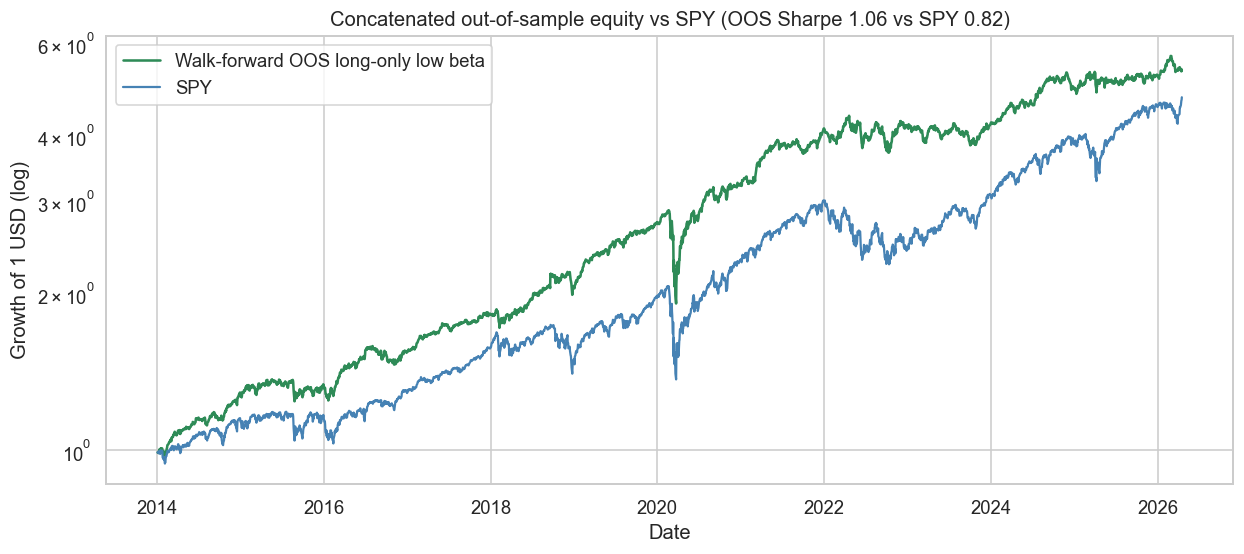

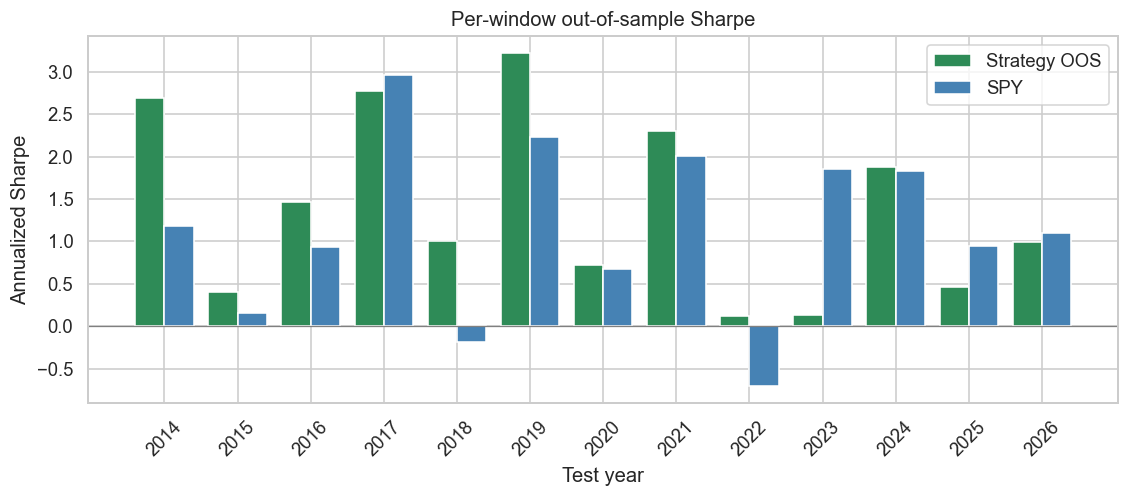

In [11]:
wf_rows, oos_parts = [], []
for ty in range(2014, 2027):
    tr0, tr1 = pd.Timestamp(ty - 4, 1, 1), pd.Timestamp(ty - 1, 12, 31)
    te0, te1 = pd.Timestamp(ty, 1, 1), pd.Timestamp(ty, 12, 31)
    cands = [(B, w) for B in WF_B for w in WF_W]
    best = max(cands, key=lambda c: sharpe(combo_rets[c].loc[tr0:tr1]))
    te = combo_rets[best].loc[te0:te1]
    if len(te) < 40:
        continue
    oos_parts.append(te)
    wf_rows.append({'TestYear': ty, 'B': best[0], 'w': best[1],
                    'TrainSharpe': sharpe(combo_rets[best].loc[tr0:tr1]),
                    'OOS_Sharpe': sharpe(te),
                    'SPY_Sharpe': sharpe(spy_ret.loc[te0:te1])})

wf_table = pd.DataFrame(wf_rows)
oos_ret = pd.concat(oos_parts).sort_index()
oos_sharpe_total = sharpe(oos_ret)
spy_oos = spy_ret.loc[oos_ret.index[0]:oos_ret.index[-1]].dropna()

display(wf_table.style.format({'w': '{:.1f}', 'TrainSharpe': '{:.2f}',
                               'OOS_Sharpe': '{:.2f}', 'SPY_Sharpe': '{:.2f}'})
        .set_caption('Walk-forward windows: chosen parameters and out-of-sample Sharpe'))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot((1.0 + oos_ret.fillna(0)).cumprod(), label='Walk-forward OOS long-only low beta',
        color='seagreen', lw=1.6)
ax.plot((1.0 + spy_oos.fillna(0)).cumprod(), label='SPY', color='steelblue', lw=1.4)
ax.set_yscale('log')
ax.set_title('Concatenated out-of-sample equity vs SPY (OOS Sharpe %.2f vs SPY %.2f)'
             % (oos_sharpe_total, sharpe(spy_oos)))
ax.set_xlabel('Date')
ax.set_ylabel('Growth of 1 USD (log)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.5))
xpos = np.arange(len(wf_table))
ax.bar(xpos - 0.2, wf_table['OOS_Sharpe'], width=0.4, label='Strategy OOS', color='seagreen')
ax.bar(xpos + 0.2, wf_table['SPY_Sharpe'], width=0.4, label='SPY', color='steelblue')
ax.set_xticks(xpos)
ax.set_xticklabels(wf_table['TestYear'], rotation=45)
ax.axhline(0, color='gray', lw=0.8)
ax.set_title('Per-window out-of-sample Sharpe')
ax.set_xlabel('Test year')
ax.set_ylabel('Annualized Sharpe')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation**: the walk-forward test is the honest version of the backtest: parameters are chosen only from past data. The parameter choices in the table are informative in themselves: if the selector keeps hopping between corners of the grid, the training signal is weak; if it settles on long windows and moderate shrinkage, the signal is stable. Because low-beta portfolios are highly correlated across parameter choices (verified in the cluster section), the parameter choice matters less than the strategy itself, so the concatenated OOS curve mostly reflects the viability of the low-beta tilt, not selection skill.

## Parameter Stability

Full-sample 6 x 6 grid: correlation window B in {60, 126, 189, 252, 378, 504} against shrinkage w in {0.0, 0.2, 0.4, 0.6, 0.8, 1.0}, evaluated on the long-only low-beta quintile. Daily return streams per combination were stored above for reuse in the Monte Carlo and cluster sections.

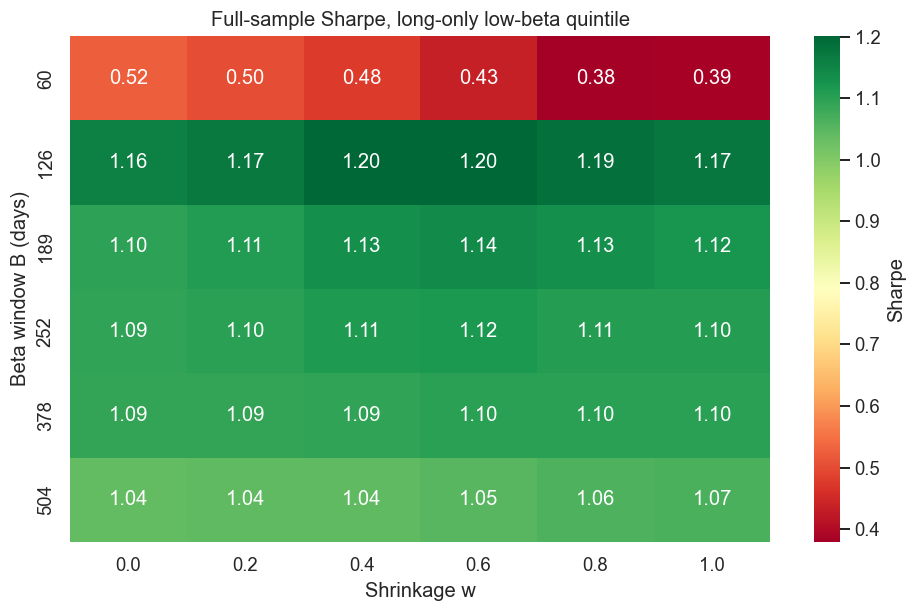

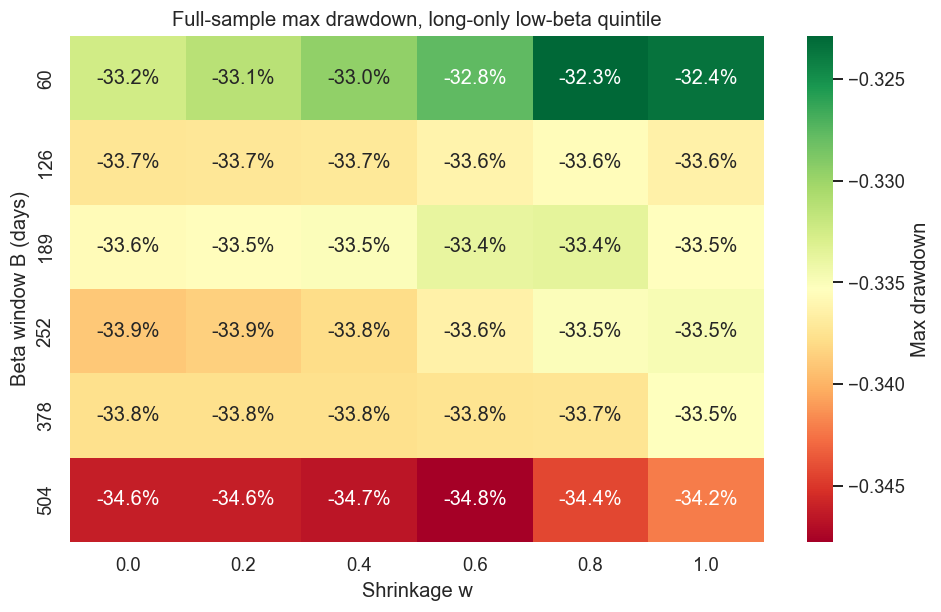

In [12]:
grid_combos = [(B, w) for B in GRID_B for w in GRID_W]
grid_sharpe = pd.DataFrame(index=GRID_B, columns=GRID_W, dtype=float)
grid_mdd = pd.DataFrame(index=GRID_B, columns=GRID_W, dtype=float)
for (B, w) in grid_combos:
    grid_sharpe.loc[B, w] = sharpe(combo_rets[(B, w)])
    grid_mdd.loc[B, w] = max_dd(combo_rets[(B, w)])

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.heatmap(grid_sharpe.astype(float), annot=True, fmt='.2f', cmap='RdYlGn',
            cbar_kws={'label': 'Sharpe'}, ax=ax)
ax.set_title('Full-sample Sharpe, long-only low-beta quintile')
ax.set_xlabel('Shrinkage w')
ax.set_ylabel('Beta window B (days)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.heatmap(grid_mdd.astype(float), annot=True, fmt='.1%', cmap='RdYlGn',
            cbar_kws={'label': 'Max drawdown'}, ax=ax)
ax.set_title('Full-sample max drawdown, long-only low-beta quintile')
ax.set_xlabel('Shrinkage w')
ax.set_ylabel('Beta window B (days)')
plt.tight_layout()
plt.show()

**Interpretation**: two things matter here. First, the gradient across B (rows): very short windows produce noisy betas and more turnover, long windows produce stable rankings; a plateau from roughly 252 to 504 days suggests the signal is not an artifact of one lookback. Second, the gradient across w (columns) is mild by construction: w only tilts within-quintile weights toward the lowest-beta names (selection is unchanged), so smooth, small variation across columns is expected and indicates the result does not hinge on the weighting detail. The chosen point (B = 252, w = 0.6) should sit inside the stable region, not on a lonely peak.

## Monte Carlo Robustness

Stationary block bootstrap (mean block length 21 trading days, geometric block lengths, 300 resamples) applied to the daily return stream of every grid combination. The same resample index matrix is reused across combinations so results are directly comparable. This preserves short-horizon autocorrelation and volatility clustering while breaking the specific historical path.

In [13]:
N_BOOT, BLOCK = 300, 21
common_idx = combo_rets[(BASE_B, BASE_W)].index
T = len(common_idx)
rng = np.random.default_rng(42)

restart = rng.random((N_BOOT, T)) < 1.0 / BLOCK
starts = rng.integers(0, T, size=(N_BOOT, T))
idx = np.empty((N_BOOT, T), dtype=np.int64)
idx[:, 0] = starts[:, 0]
cur = starts[:, 0].copy()
for t in range(1, T):
    cur = np.where(restart[:, t], starts[:, t], (cur + 1) % T)
    idx[:, t] = cur

def boot_stats(arr):
    sims = arr[idx]                                  # (N_BOOT, T)
    mu = sims.mean(axis=1)
    sd = sims.std(axis=1)
    sh = np.where(sd > 0, mu / sd * np.sqrt(ANN), 0.0)
    eq = np.cumprod(1.0 + sims, axis=1)
    dd = (eq / np.maximum.accumulate(eq, axis=1) - 1.0).min(axis=1)
    return sh, dd

boot_sharpe, boot_mdd = {}, {}
for c in grid_combos:
    arr = combo_rets[c].reindex(common_idx).fillna(0.0).values
    boot_sharpe[c], boot_mdd[c] = boot_stats(arr)
print('Bootstrap done: %d combos x %d resamples x %d days in %.1fs total'
      % (len(grid_combos), N_BOOT, T, time.time() - T0))

Bootstrap done: 36 combos x 300 resamples x 4097 days in 20.9s total


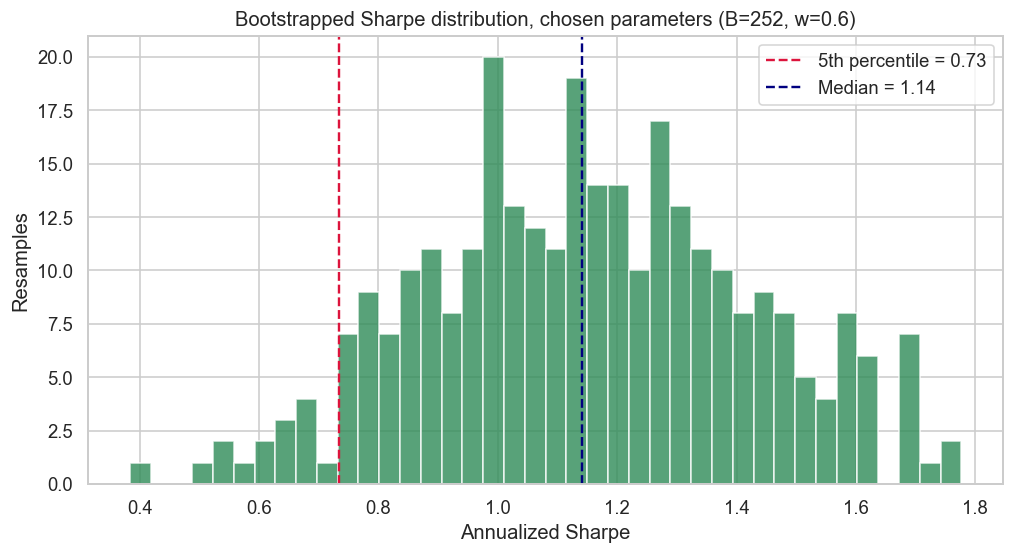

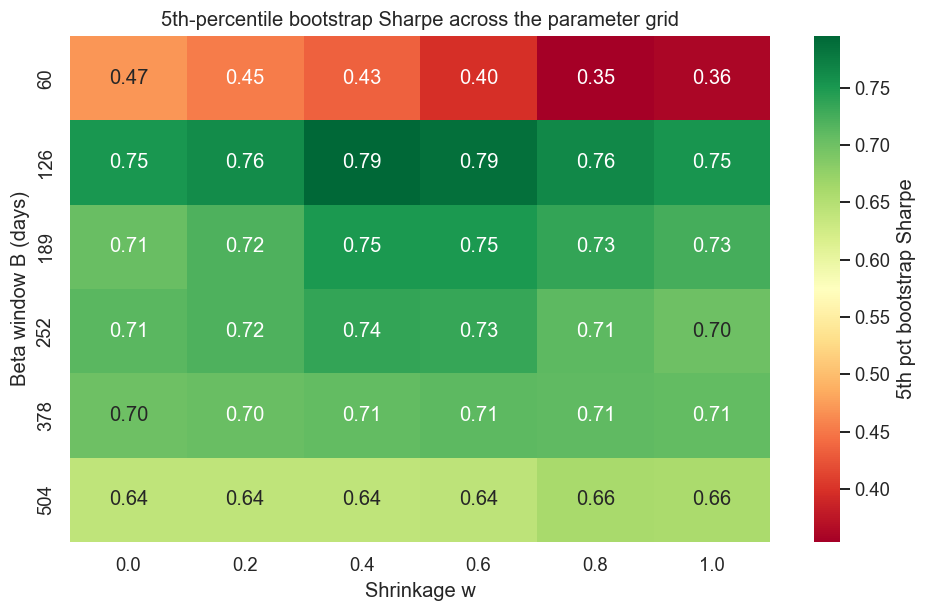

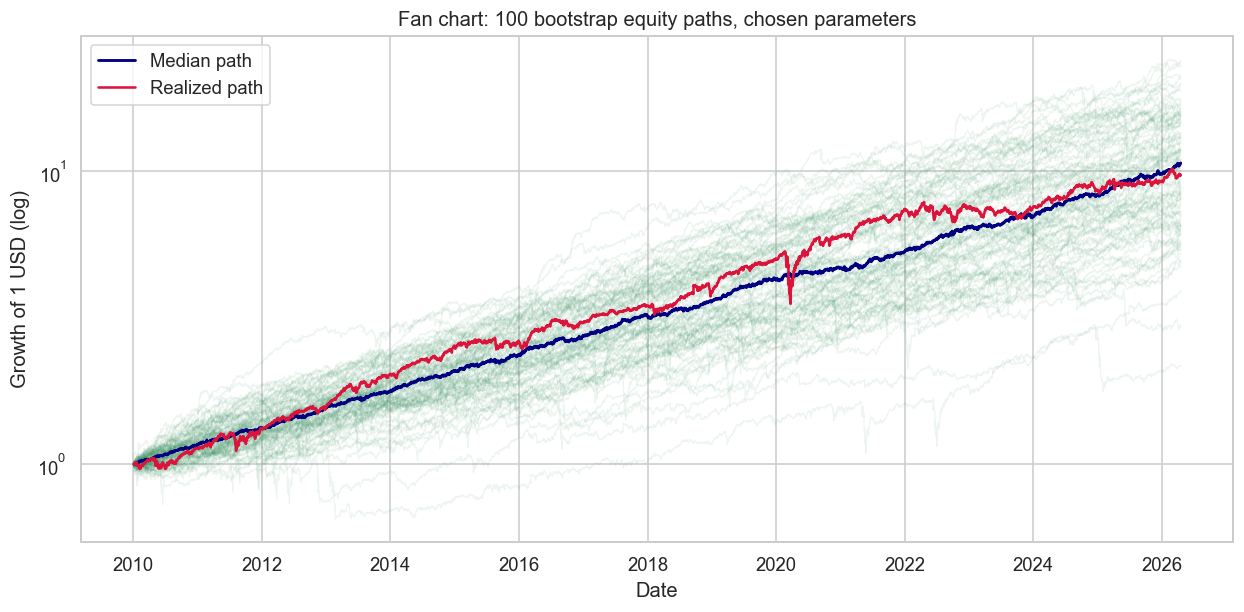

,Sharpe,MaxDD
p5,0.73,-39.5%
p25,0.96,-33.6%
p50,1.14,-30.2%
p75,1.33,-18.1%
p95,1.61,-13.4%


In [14]:
chosen = (BASE_B, BASE_W)
sh_ch, dd_ch = boot_sharpe[chosen], boot_mdd[chosen]
mc_p5 = float(np.percentile(sh_ch, 5))
mc_p50 = float(np.percentile(sh_ch, 50))

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(sh_ch, bins=40, color='seagreen', alpha=0.8, edgecolor='white')
ax.axvline(mc_p5, color='crimson', ls='--', label='5th percentile = %.2f' % mc_p5)
ax.axvline(mc_p50, color='navy', ls='--', label='Median = %.2f' % mc_p50)
ax.set_title('Bootstrapped Sharpe distribution, chosen parameters (B=252, w=0.6)')
ax.set_xlabel('Annualized Sharpe')
ax.set_ylabel('Resamples')
ax.legend()
plt.tight_layout()
plt.show()

p5_grid = pd.DataFrame(index=GRID_B, columns=GRID_W, dtype=float)
for (B, w) in grid_combos:
    p5_grid.loc[B, w] = float(np.percentile(boot_sharpe[(B, w)], 5))
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.heatmap(p5_grid.astype(float), annot=True, fmt='.2f', cmap='RdYlGn',
            cbar_kws={'label': '5th pct bootstrap Sharpe'}, ax=ax)
ax.set_title('5th-percentile bootstrap Sharpe across the parameter grid')
ax.set_xlabel('Shrinkage w')
ax.set_ylabel('Beta window B (days)')
plt.tight_layout()
plt.show()

arr_ch = combo_rets[chosen].reindex(common_idx).fillna(0.0).values
paths = np.cumprod(1.0 + arr_ch[idx[:100]], axis=1)
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(common_idx, paths.T, color='seagreen', alpha=0.08, lw=0.8)
ax.plot(common_idx, np.median(paths, axis=0), color='navy', lw=1.8, label='Median path')
ax.plot(common_idx, np.cumprod(1.0 + arr_ch), color='crimson', lw=1.6, label='Realized path')
ax.set_yscale('log')
ax.set_title('Fan chart: 100 bootstrap equity paths, chosen parameters')
ax.set_xlabel('Date')
ax.set_ylabel('Growth of 1 USD (log)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

pct_levels = [5, 25, 50, 75, 95]
pct_table = pd.DataFrame({
    'Sharpe': np.percentile(sh_ch, pct_levels),
    'MaxDD': np.percentile(dd_ch, pct_levels),
}, index=['p%d' % p for p in pct_levels])
display(pct_table.style.format({'Sharpe': '{:.2f}', 'MaxDD': '{:.1%}'})
        .set_caption('Bootstrap percentiles, chosen parameters (B=252, w=0.6)'))

**Interpretation**: the bootstrap answers how much of the historical Sharpe is path luck. The 5th percentile is the number to plan around: if it stays clearly positive, the strategy survives most reshufflings of history. The 5th-percentile heatmap doubles as a joint robustness check: parameter sets that only look good on the realized path fall apart here. The fan chart shows the dispersion of terminal wealth; the realized path sitting inside the fan (rather than hugging its top edge) means the backtest was not an unusually lucky draw.

## Cluster Analysis

Two views. First, hierarchical clustering of the 36 parameter-set daily return streams (distance = 1 - correlation, average linkage) to check whether the chosen parameters sit in a broad, stable cluster. Second, market regime clustering: KMeans with k = 3 on rolling 63-day SPY volatility and rolling 126-day SPY return, then strategy Sharpe per regime.

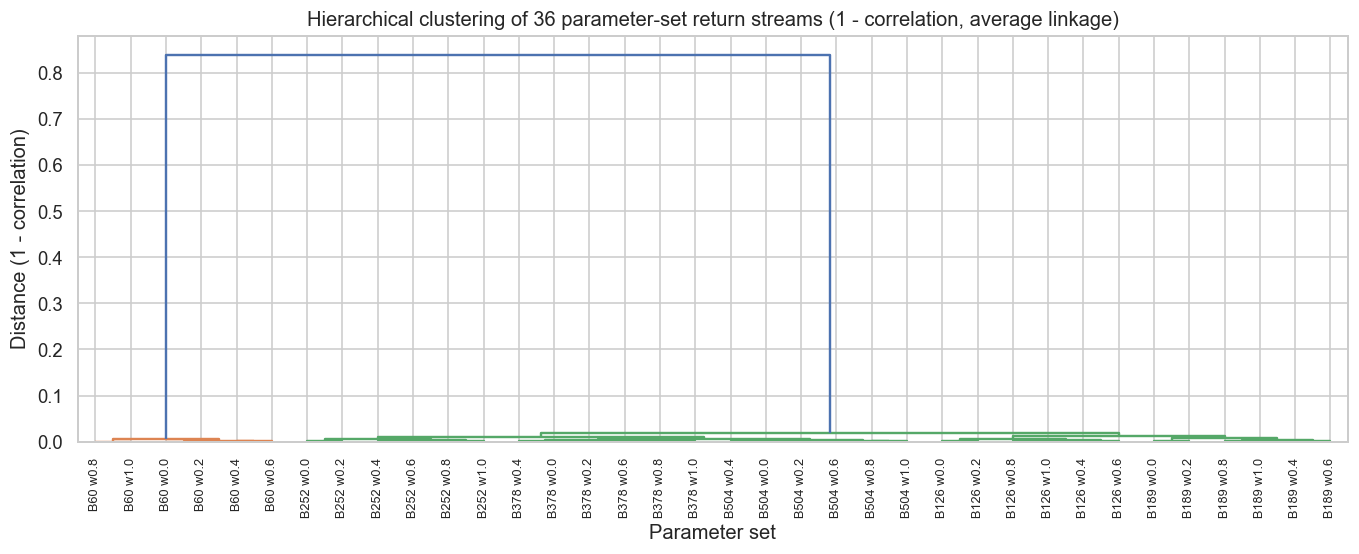

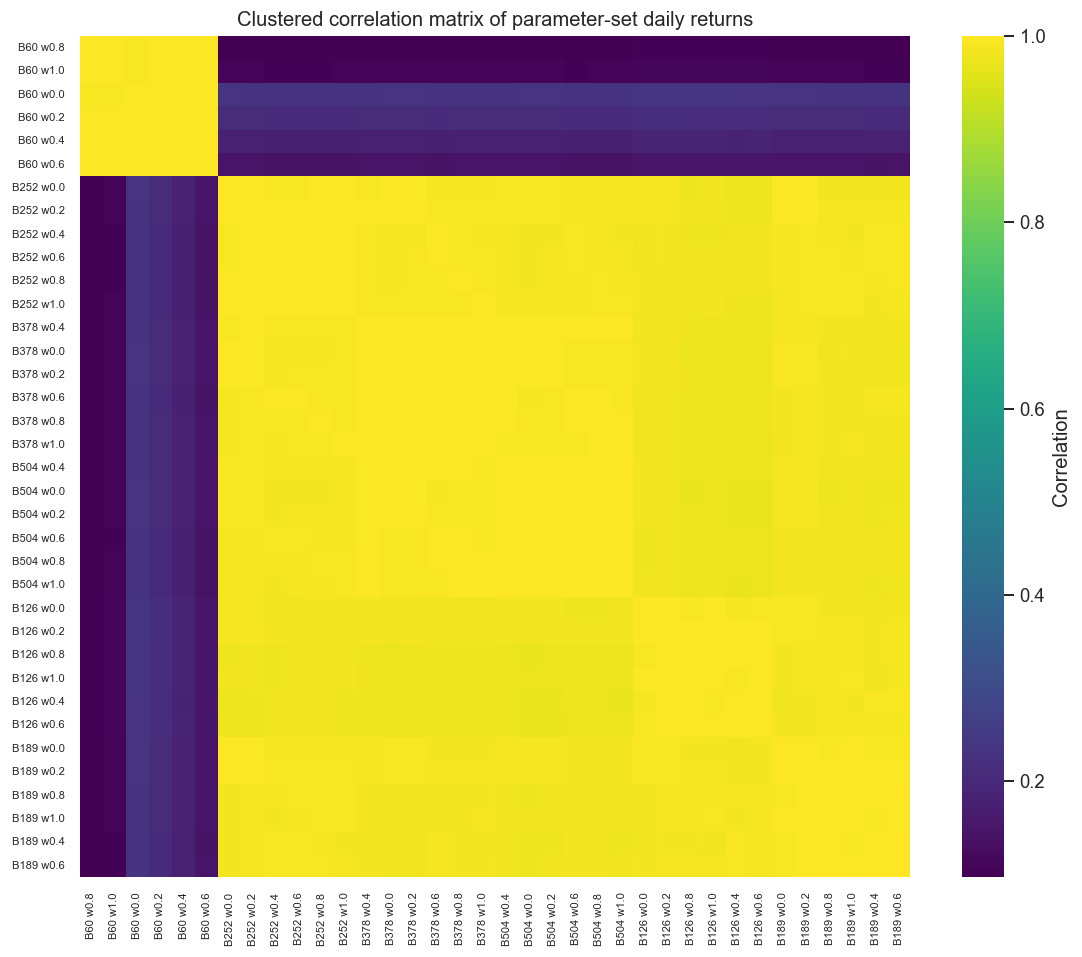

Pairwise correlations: min 0.097, median 0.984, max 1.000


In [15]:
names = ['B%d w%.1f' % c for c in grid_combos]
stream_mat = pd.DataFrame(
    {n: combo_rets[c].reindex(common_idx).fillna(0.0) for n, c in zip(names, grid_combos)})
C = stream_mat.corr()

dist = squareform((1.0 - C.values), checks=False)
Z = hierarchy.linkage(dist, method='average')

fig, ax = plt.subplots(figsize=(12, 5))
dn = hierarchy.dendrogram(Z, labels=names, leaf_rotation=90, ax=ax,
                          color_threshold=0.7 * np.max(Z[:, 2]))
ax.set_title('Hierarchical clustering of 36 parameter-set return streams (1 - correlation, average linkage)')
ax.set_xlabel('Parameter set')
ax.set_ylabel('Distance (1 - correlation)')
plt.tight_layout()
plt.show()

order = dn['leaves']
C_ord = C.iloc[order, order]
fig, ax = plt.subplots(figsize=(10, 8.5))
sns.heatmap(C_ord, cmap='viridis', vmin=C.values.min(), vmax=1.0,
            xticklabels=True, yticklabels=True, cbar_kws={'label': 'Correlation'}, ax=ax)
ax.tick_params(axis='both', labelsize=7)
ax.set_title('Clustered correlation matrix of parameter-set daily returns')
plt.tight_layout()
plt.show()

off_diag = C.values[np.triu_indices_from(C.values, k=1)]
print('Pairwise correlations: min %.3f, median %.3f, max %.3f'
      % (off_diag.min(), np.median(off_diag), off_diag.max()))

**Interpretation**: the dendrogram groups primarily by beta window B (shrinkage w only re-tilts weights inside the same quintile, so same-B streams are near-duplicates). If the minimum pairwise correlation printed above is high, every parameterization is essentially one trade: a low-beta tilt on liquid US equities. That is good news for robustness (the chosen point B = 252, w = 0.6 sits inside a broad cluster of near-identical strategies, not a fragile island) and bad news for diversification (running several parameterizations adds little).

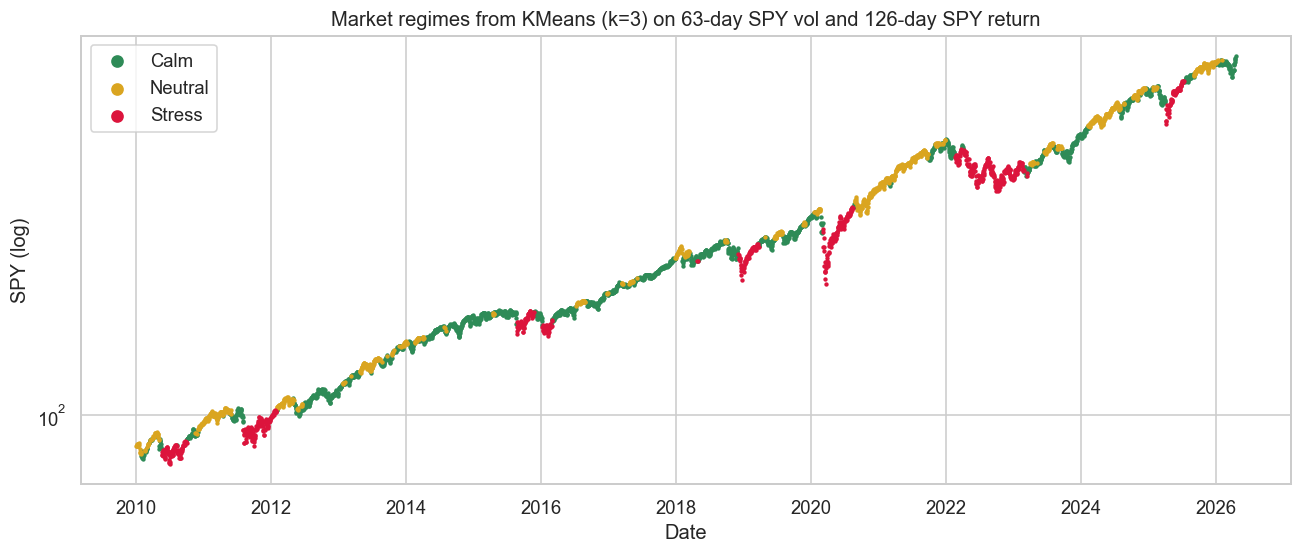

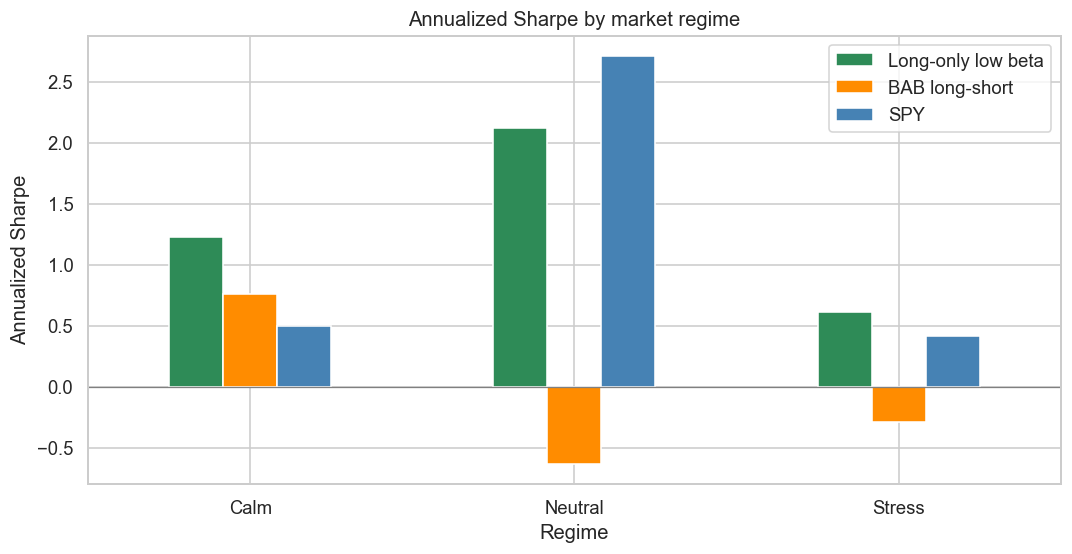

,Days,Long-only low beta,BAB long-short,SPY
Regime,,,,
Calm,2142,1.23,0.76,0.50
Neutral,1137,2.12,-0.63,2.71
Stress,818,0.61,-0.29,0.42


In [16]:
# Regime clustering on SPY features
feat = pd.DataFrame({
    'vol63': spy_ret.rolling(63).std() * np.sqrt(ANN),
    'ret126': spy_close.pct_change(126),
}).dropna().loc[BT_START:close.index[-1]]
km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(
    StandardScaler().fit_transform(feat.values))
lab = pd.Series(km.labels_, index=feat.index)
vol_order = feat.groupby(lab)['vol63'].mean().sort_values().index.tolist()
regime_names = {vol_order[0]: 'Calm', vol_order[1]: 'Neutral', vol_order[2]: 'Stress'}
regime = lab.map(regime_names)
reg_colors = {'Calm': 'seagreen', 'Neutral': 'goldenrod', 'Stress': 'crimson'}

fig, ax = plt.subplots(figsize=(11.5, 5))
spy_plot = spy_close.loc[regime.index]
for rname in ['Calm', 'Neutral', 'Stress']:
    m = regime == rname
    ax.scatter(spy_plot.index[m], spy_plot[m], s=3, color=reg_colors[rname], label=rname)
ax.set_yscale('log')
ax.set_title('Market regimes from KMeans (k=3) on 63-day SPY vol and 126-day SPY return')
ax.set_xlabel('Date')
ax.set_ylabel('SPY (log)')
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

reg_stats = []
for rname in ['Calm', 'Neutral', 'Stress']:
    days = regime.index[regime == rname]
    reg_stats.append({
        'Regime': rname,
        'Days': len(days),
        'Long-only low beta': sharpe(lo_ret.reindex(days).dropna()),
        'BAB long-short': sharpe(bab_ret.reindex(days).dropna()),
        'SPY': sharpe(spy_bt.reindex(days).dropna()),
    })
reg_df = pd.DataFrame(reg_stats).set_index('Regime')

fig, ax = plt.subplots(figsize=(9.5, 5))
reg_df[['Long-only low beta', 'BAB long-short', 'SPY']].plot(
    kind='bar', ax=ax, color=['seagreen', 'darkorange', 'steelblue'])
ax.axhline(0, color='gray', lw=0.8)
ax.set_title('Annualized Sharpe by market regime')
ax.set_xlabel('Regime')
ax.set_ylabel('Annualized Sharpe')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
display(reg_df.style.format({'Long-only low beta': '{:.2f}', 'BAB long-short': '{:.2f}',
                             'SPY': '{:.2f}'})
        .set_caption('Sharpe per regime and days spent in each'))

**Interpretation**: BAB is known to suffer in sharp risk-on rallies (high-beta junk squeezes the short leg, and betas compress) and to shine in calm and stressed markets where the low-beta cross-section is well behaved. The long-only variant behaves differently: it is still net long equities, so it loses money in Stress regimes in absolute terms, but typically loses less than SPY, which is the defensive property the live account would be buying. If the regime bars show the long-only Sharpe lagging SPY badly in Calm regimes, that is the cost of the tilt: it gives up upside in strong bull runs.

## Decision Summary

Verdict, expected live Sharpe range from the bootstrap, overlap with existing exposures (SPY and a 12-1 momentum long-only proxy built from the same panel), deployment notes and risks.

In [17]:
# 12-1 momentum long-only proxy from the same stock panel (top decile, equal weight, monthly)
mom_score = (close.shift(21) / close.shift(252) - 1.0).loc[month_ends]
mom_rows = {}
for d in mom_score.index:
    if d < REB_START:
        continue
    v = mom_score.loc[d].dropna()
    v = v[close.loc[d, v.index].notna()]
    if len(v) < MIN_NAMES:
        continue
    sel = v.nlargest(max(int(len(v) * 0.10), 10)).index
    mom_rows[d] = pd.Series(1.0 / len(sel), index=sel)
mom_ret, _ = weights_to_returns(pd.DataFrame(mom_rows).T, rets)
mom_ret = mom_ret.loc[BT_START:]

def monthly_corr(a, b):
    ma, mb = monthly_returns(a.dropna()), monthly_returns(b.dropna())
    j = ma.index.intersection(mb.index)
    return float(ma.loc[j].corr(mb.loc[j]))

corr_lo_spy = monthly_corr(lo_ret, spy_bt)
corr_lo_mom = monthly_corr(lo_ret, mom_ret)
corr_bab_spy = monthly_corr(bab_ret, spy_bt)
corr_bab_mom = monthly_corr(bab_ret, mom_ret)

verdict = pd.DataFrame({
    'Full-sample Sharpe': [sharpe(bab_ret), sharpe(lo_ret), sharpe(spy_bt)],
    'CAGR': [metrics_row(bab_ret)['CAGR'], metrics_row(lo_ret)['CAGR'],
             metrics_row(spy_bt)['CAGR']],
    'MaxDD': [max_dd(bab_ret), max_dd(lo_ret), max_dd(spy_bt)],
    'WF OOS Sharpe': [np.nan, oos_sharpe_total, sharpe(spy_oos)],
    'MC Sharpe p5': [np.nan, mc_p5, np.nan],
    'MC Sharpe p50': [np.nan, mc_p50, np.nan],
    'Monthly corr vs SPY': [corr_bab_spy, corr_lo_spy, 1.0],
    'Monthly corr vs momentum': [corr_bab_mom, corr_lo_mom, monthly_corr(spy_bt, mom_ret)],
}, index=['BAB long-short', 'Long-only low beta Q1', 'SPY'])
display(verdict.style.format({
    'Full-sample Sharpe': '{:.2f}', 'CAGR': '{:.2%}', 'MaxDD': '{:.1%}',
    'WF OOS Sharpe': '{:.2f}', 'MC Sharpe p5': '{:.2f}', 'MC Sharpe p50': '{:.2f}',
    'Monthly corr vs SPY': '{:.2f}', 'Monthly corr vs momentum': '{:.2f}'}, na_rep='n/a')
    .set_caption('Verdict table (momentum proxy: top decile of 12-1 momentum, equal weight, monthly)'))

# Sector concentration of the current low-beta basket
cur_w = lo_wdf.iloc[-1]
cur_w = cur_w[cur_w > 0]
sec_w = cur_w.groupby(cur_w.index.map(sector_map).fillna('Unknown')).sum()
sec_w = sec_w.sort_values(ascending=False).rename('Weight').to_frame()
display(sec_w.head(8).style.format({'Weight': '{:.1%}'})
        .set_caption('Top sector weights of the current low-beta basket (%s, %d names)'
                     % (lo_wdf.index[-1].date(), len(cur_w))))

headline = {
    'decile_sharpe_declining': monotonic,
    'decile_spearman': round(rho_dec, 3),
    'bab_sharpe': round(sharpe(bab_ret), 3),
    'longonly_sharpe': round(sharpe(lo_ret), 3),
    'spy_sharpe': round(sharpe(spy_bt), 3),
    'wf_oos_sharpe': round(oos_sharpe_total, 3),
    'mc_p5': round(mc_p5, 3),
    'mc_p50': round(mc_p50, 3),
    'corr_lo_spy': round(corr_lo_spy, 3),
    'corr_lo_mom': round(corr_lo_mom, 3),
    'avg_sml_slope': round(avg_slope, 5),
    'runtime_min': round((time.time() - T0) / 60.0, 1),
}
print('HEADLINE ' + json.dumps(headline))

,Full-sample Sharpe,CAGR,MaxDD,WF OOS Sharpe,MC Sharpe p5,MC Sharpe p50,Monthly corr vs SPY,Monthly corr vs momentum
BAB long-short,-0.18,n/a,-127.6%,n/a,n/a,n/a,-0.25,-0.27
Long-only low beta Q1,1.12,15.03%,-33.6%,1.06,0.73,1.14,0.73,0.64
SPY,0.85,14.08%,-33.7%,0.82,n/a,n/a,1.00,0.84


,Weight
Consumer Staples,23.7%
Utilities,19.2%
Energy,14.0%
Financials,13.7%
Health Care,7.4%
Real Estate,6.1%
Industrials,5.7%
Consumer Discretionary,4.1%


HEADLINE {"decile_sharpe_declining": true, "decile_spearman": -0.915, "bab_sharpe": -0.176, "longonly_sharpe": 1.117, "spy_sharpe": 0.854, "wf_oos_sharpe": 1.061, "mc_p5": 0.734, "mc_p50": 1.142, "corr_lo_spy": 0.731, "corr_lo_mom": 0.641, "avg_sml_slope": 0.08769, "runtime_min": 0.4}


**Deployment notes**:

- The deployable variant is the long-only low-beta quintile (about 100 to 120 names at 600-stock universe scale; on the live account this can be truncated to the lowest-beta 30 to 50 names with near-identical behavior since weights are close to equal).
- Fits the repo contract directly: a `generate_signals(budget, strategy_id, held_symbols)` module that ranks the universe by shrunk 252-day beta at month end and rebalances monthly. Suggested initial budget: 5k to 10k USD paper, in line with the other single-style sleeves.
- Expected live Sharpe range from the bootstrap: use the 5th percentile to median band (MC Sharpe p5 to p50 in the verdict table) as the planning range, and haircut further for survivorship bias in the cache universe.

**Risks**:

- Beta-compression regimes: when cross-sectional beta dispersion collapses (see the percentile band chart), the sort carries little information and the portfolio drifts toward a generic defensive-equity basket.
- Sharp risk-on rallies: the low-beta tilt lags the market badly when high-beta names squeeze (2020 H2, 2023 AI rally); expect painful relative drawdowns even when absolute drawdowns are shallow.
- Sector concentration: low-beta baskets structurally overweight utilities, staples and insurance (see the sector table above), so the sleeve embeds rate sensitivity; consider a per-sector cap if deployed at size.
- Survivorship bias: the cache holds current index members, which flatters long-only equity backtests; the walk-forward and bootstrap numbers inherit this bias.
- The BAB long-short numbers exclude borrow and financing costs and are not deployable on the long-only Alpaca account; they are shown as the canonical factor benchmark.